#  Notebook 05: Outlier Detection & Temporal Splitting Strategy

##  Σύνοψη Φάσης
Σε αυτή τη φάση εφαρμόζουμε το feedback του επιβλέποντος καθηγητή για την ποιοτική αναβάθμιση του dataset. Η ανάλυση επικεντρώνεται στη στατιστική εξυγίανση των δεδομένων και στον ορθό χρονικό διαχωρισμό τους, διασφαλίζοντας ότι τα μοντέλα (Mamba, XGBoost) θα εκπαιδευτούν σε "καθαρά" δεδομένα χωρίς διαρροή πληροφορίας (Data Leakage).

##  Στόχοι
1. **Z-Score Outlier Detection:** Εντοπισμός ακραίων τιμών στην αιολική ισχύ με χρήση στατιστικών ορίων.
2. **Temporal Splitting:** Διαχωρισμός του dataset σε σύνολα Train, Validation και Test βάσει χρονοσειράς.
3. **Data Integrity Check:** Επιβεβαίωση της συνέπειας των δεδομένων μετά τον καθαρισμό.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Σύνδεση με το κεντρικό config.py (ανεβαίνουμε ένα επίπεδο από τον φάκελο notebooks)
sys.path.append(str(Path.cwd().parent))

# Εδώ είναι η διόρθωση: Προσθέσαμε το DATA_PROCESSED στην εισαγωγή
from src.config import (
    FINAL_DATASET, 
    Z_SCORE_THRESHOLD, 
    TARGET_COLUMN, 
    TRAIN_END_DATE, 
    VAL_END_DATE, 
    DATA_PROCESSED
)

# 1. Φόρτωση του "Golden" Dataset (1.6M+ εγγραφές)
df = pd.read_csv(FINAL_DATASET)
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Ταξινόμηση βάσει χρόνου - Απαραίτητο για Time Series
df = df.sort_values('timestamp').reset_index(drop=True)

print(f"Επιτυχής φόρτωση: {len(df):,} δείγματα.")
print(f"Τα αποτελέσματα θα αποθηκευτούν στο: {DATA_PROCESSED}")

Επιτυχής φόρτωση: 1,655,885 δείγματα.
Τα αποτελέσματα θα αποθηκευτούν στο: C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed


## Section 1: Outlier Detection (Z-Score Analysis)

Σε αυτή την ενότητα εφαρμόζουμε τη μέθοδο του **Z-score** για τον εντοπισμό ακραίων τιμών στην αιολική ισχύ. Το όριο έχει οριστεί στα **3.0 standard deviations** ($\sigma$) στο `config.py`, το οποίο αποτελεί το standard για τον καθαρισμό θορύβου σε μεγάλα datasets αιολικής ενέργειας.

$$
Z = \frac{x - \mu}{\sigma}
$$

Για την αποφυγή **information leakage**, τα όρια του **Z-score** υπολογίζονται αποκλειστικά από το **train set** και στη συνέχεια εφαρμόζονται στα **validation** και **test** σύνολα, διατηρώντας έτσι τη μεθοδολογική εγκυρότητα του χρονικού πειράματος.

In [2]:
# Δες όλα τα διαθέσιμα ονόματα στηλών
print(df.columns.tolist())

['timestamp', 'nwp_fcst_horiz_hours', 'T_HAG_2_M', 'RELHUM_HAG_2_M', 'PS_SFC_0_M', 'U_GVL_58_HL', 'V_GVL_58_HL', 'U_GVL_60_HL', 'V_GVL_60_HL', 'ASWDIFDS_SFC_0_M', 'ASWDIRS_SFC_0_M', 'U_GVL_58_HL_m1', 'V_GVL_58_HL_m1', 'U_GVL_60_HL_m1', 'V_GVL_60_HL_m1', 'U_GVL_58_HL_p1', 'V_GVL_58_HL_p1', 'U_GVL_60_HL_p1', 'V_GVL_60_HL_p1', 'ws_ref', 'Wind_Speed_100m_ms', 'test_flag', 'Power_Output_Normalized', 'Baseline_Prediction', 'park_id', 'hour', 'month', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'Power_Output_Normalized_lag_1', 'Power_Output_Normalized_lag_3', 'Power_Output_Normalized_lag_6', 'Wind_Speed_100m_ms_lag_1', 'Wind_Speed_100m_ms_lag_3', 'Wind_Speed_100m_ms_lag_6', 'power_rolling_mean_6h', 'power_rolling_std_6h', 'lat', 'lon']


##  Section 1.2: Temporal Splitting & Data Integrity Check

Μετά τον καθαρισμό των outliers, προχωράμε στον χρονικό διαχωρισμό του dataset. Η στρατηγική μας βασίζεται στην αποφυγή του **Look-ahead Bias**, διασφαλίζοντας ότι το μοντέλο αξιολογείται σε δεδομένα που χρονικά έπονται της εκπαίδευσης.

###  Split Configuration (from config.py):
* **Training Set:** Έως 2019-12-31 (Περίοδος βάσης)
* **Validation Set:** 2020-01-01 έως 2020-06-30 (Ευθυγράμμιση παραμέτρων)
* **Test Set:** 2020-07-01 έως τέλος (Τελική αξιολόγηση Digital Twin)

###  Validation Protocol:
Χρησιμοποιούμε `assert` statements για να επιβεβαιώσουμε ότι δεν υπάρχει επικάλυψη (overlap) μεταξύ των συνόλων, εγγυώμενοι την επιστημονική εγκυρότητα των μελλοντικών προβλέψεων.

In [3]:
# ============================================================
# Temporal Split Strategy (Χρονικός διαχωρισμός συνόλων)
# ------------------------------------------------------------
# Χωρίζουμε το dataset σε Train / Validation / Test με βάση
# τα χρονικά όρια του config.py.
#
# Σημαντικό:
# - χρησιμοποιούμε .copy() για ασφαλή ανεξάρτητα subsets
# - αποφεύγουμε data leakage μεταξύ των συνόλων
# ============================================================

train_df = df[df['timestamp'] <= TRAIN_END_DATE].copy()
val_df = df[(df['timestamp'] > TRAIN_END_DATE) & (df['timestamp'] <= VAL_END_DATE)].copy()
test_df = df[df['timestamp'] > VAL_END_DATE].copy()

# ------------------------------------------------------------
# Split Summary (Σύνοψη δειγμάτων ανά σύνολο)
# ------------------------------------------------------------
print("Temporal Split Summary (Samples):")
print(f"- Train: {len(train_df):,}")
print(f"- Validation: {len(val_df):,}")
print(f"- Test: {len(test_df):,}")

# ------------------------------------------------------------
# Data Leakage Protection (Έλεγχος χρονικής επικάλυψης)
# ------------------------------------------------------------
assert train_df['timestamp'].max() < val_df['timestamp'].min(), "Train/Val overlap detected."
assert val_df['timestamp'].max() < test_df['timestamp'].min(), "Val/Test overlap detected."

print("\nVerification Passed: No temporal leakage detected.")

Temporal Split Summary (Samples):
- Train: 1,244,004
- Validation: 329,084
- Test: 82,797

Verification Passed: No temporal leakage detected.


In [4]:
# ============================================================
# Train-Based Outlier Detection & Clipping
# (Εντοπισμός ακραίων τιμών και clipping με train-only στατιστικά)
# ------------------------------------------------------------
# Πολύ σημαντικό:
# Τα thresholds υπολογίζονται ΜΟΝΟ από το train set ώστε
# να μην εισάγουμε πληροφορία από Validation/Test
# (no information leakage).
#
# Εδώ εφαρμόζουμε Z-score analysis μόνο για το target:
# Power_Output_Normalized
# ============================================================

# ------------------------------------------------------------
# Step 1: Compute train statistics (Υπολογισμός train-only mean/std)
# ------------------------------------------------------------
mean_val = train_df[TARGET_COLUMN].mean()
std_val = train_df[TARGET_COLUMN].std()

# Προστασία από μηδενική τυπική απόκλιση (zero-std safeguard)
if std_val == 0:
    raise ValueError(f"Standard deviation for {TARGET_COLUMN} is zero. Z-score cannot be computed.")

# ------------------------------------------------------------
# Step 2: Define clipping thresholds (Όρια clipping)
# ------------------------------------------------------------
upper_limit = mean_val + Z_SCORE_THRESHOLD * std_val
lower_limit = mean_val - Z_SCORE_THRESHOLD * std_val

print("Train-based clipping limits:")
print(f"Lower limit: {lower_limit:.4f}")
print(f"Upper limit: {upper_limit:.4f}")

# ------------------------------------------------------------
# Step 3: Count outliers per split using train-based thresholds
# (Καταμέτρηση ακραίων τιμών ανά σύνολο)
# ------------------------------------------------------------
train_z = ((train_df[TARGET_COLUMN] - mean_val) / std_val).abs()
val_z = ((val_df[TARGET_COLUMN] - mean_val) / std_val).abs()
test_z = ((test_df[TARGET_COLUMN] - mean_val) / std_val).abs()

train_outliers = train_z > Z_SCORE_THRESHOLD
val_outliers = val_z > Z_SCORE_THRESHOLD
test_outliers = test_z > Z_SCORE_THRESHOLD

print("\nOutlier counts (based on train statistics):")
print(f"Train: {train_outliers.sum():,} / {len(train_df):,} ({100 * train_outliers.mean():.4f}%)")
print(f"Val:   {val_outliers.sum():,} / {len(val_df):,} ({100 * val_outliers.mean():.4f}%)")
print(f"Test:  {test_outliers.sum():,} / {len(test_df):,} ({100 * test_outliers.mean():.4f}%)")

# ------------------------------------------------------------
# Step 4: Apply clipping (Αποκοπή ακραίων τιμών)
# ------------------------------------------------------------
for dataset in [train_df, val_df, test_df]:
    dataset[TARGET_COLUMN] = dataset[TARGET_COLUMN].clip(
        lower=lower_limit,
        upper=upper_limit
    )

print(f"\nClipping applied. Values restricted between {lower_limit:.4f} and {upper_limit:.4f}")

Train-based clipping limits:
Lower limit: -0.0450
Upper limit: 0.0702

Outlier counts (based on train statistics):
Train: 2,170 / 1,244,004 (0.1744%)
Val:   941 / 329,084 (0.2859%)
Test:  0 / 82,797 (0.0000%)

Clipping applied. Values restricted between -0.0450 and 0.0702


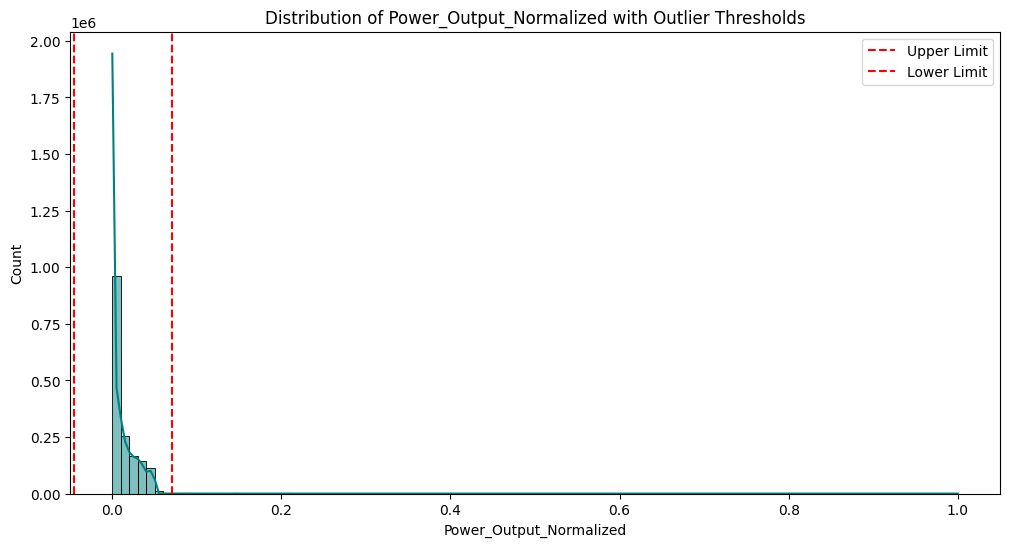

In [5]:
# Οπτικοποίηση της κατανομής και των ορίων Z-score
plt.figure(figsize=(12, 6))
sns.histplot(df[TARGET_COLUMN], bins=100, kde=True, color='teal')
plt.axvline(mean_val + Z_SCORE_THRESHOLD * std_val, color='red', linestyle='--', label='Upper Limit')
plt.axvline(mean_val - Z_SCORE_THRESHOLD * std_val, color='red', linestyle='--', label='Lower Limit')
plt.title(f"Distribution of {TARGET_COLUMN} with Outlier Thresholds")
plt.legend()
plt.show()

In [6]:
# Εφαρμογή Clipping (αντικατάσταση ακραίων τιμών με τα όρια)
upper_limit = mean_val + Z_SCORE_THRESHOLD * std_val
lower_limit = mean_val - Z_SCORE_THRESHOLD * std_val

for dataset in [train_df, val_df, test_df]:
    dataset[TARGET_COLUMN] = dataset[TARGET_COLUMN].clip(lower=lower_limit, upper=upper_limit)

print(f"Clipping applied. Values restricted between {lower_limit:.4f} and {upper_limit:.4f}")

Clipping applied. Values restricted between -0.0450 and 0.0702


In [7]:
# ============================================================
# Final Integrity Check & Export
# (Τελικός έλεγχος ακεραιότητας και αποθήκευση των split datasets)
# ============================================================

# ------------------------------------------------------------
# Step 1: Null Value Check (Έλεγχος ελλειπουσών τιμών)
# Επιβεβαιώνουμε ότι μετά το clipping / preprocessing
# δεν υπάρχουν missing values στο target column.
# ------------------------------------------------------------
print("Τελικός έλεγχος ακεραιότητας:")

for name, dset in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    nulls = dset[TARGET_COLUMN].isnull().sum()
    print(f" - {name} set: {nulls} null values found.")

# ------------------------------------------------------------
# Step 2: Output Paths (Ορισμός μονοπατιών αποθήκευσης)
# Χρησιμοποιούμε το DATA_PROCESSED από το config.py ώστε
# όλα τα τελικά αρχεία να αποθηκεύονται κεντρικά και σωστά.
# ------------------------------------------------------------
train_file = DATA_PROCESSED / "train_final.csv"
val_file = DATA_PROCESSED / "val_final.csv"
test_file = DATA_PROCESSED / "test_final.csv"

# ------------------------------------------------------------
# Step 3: Save Final Splits (Αποθήκευση τελικών συνόλων)
# Αποθηκεύουμε τα train / validation / test datasets για χρήση
# στα επόμενα notebooks μοντελοποίησης.
# ------------------------------------------------------------
train_df.to_csv(train_file, index=False)
val_df.to_csv(val_file, index=False)
test_df.to_csv(test_file, index=False)

# ------------------------------------------------------------
# Step 4: Export Confirmation (Επιβεβαίωση αποθήκευσης)
# ------------------------------------------------------------
print(f"\nΕπιτυχία! Τα τελικά datasets αποθηκεύτηκαν στο: {DATA_PROCESSED}")
print(f"Αρχεία: {train_file.name}, {val_file.name}, {test_file.name}")

Τελικός έλεγχος ακεραιότητας:
 - Train set: 0 null values found.
 - Val set: 0 null values found.
 - Test set: 0 null values found.

Επιτυχία! Τα τελικά datasets αποθηκεύτηκαν στο: C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed
Αρχεία: train_final.csv, val_final.csv, test_final.csv


## Conclusion & Phase Completion

Η φάση της προετοιμασίας δεδομένων ολοκληρώθηκε επιτυχώς. Το dataset του Kassel είναι πλέον χρονικά διαχωρισμένο και καθαρισμένο με train-based clipping, ώστε να είναι έτοιμο για το επόμενο στάδιο μοντελοποίησης.

### Key Results:
- **Outlier Handling:** Εφαρμόστηκε clipping στο target `Power_Output_Normalized` με train-based thresholds από **-0.0450 έως 0.0702** (Z-score 3.0).
- **Outlier Counts:** Εντοπίστηκαν ακραίες τιμές με βάση τα στατιστικά του train set:
  - Train: **2,170 / 1,244,004 (0.1744%)**
  - Validation: **941 / 329,084 (0.2859%)**
  - Test: **0 / 82,797 (0.0000%)**
- **Data Splits:** Δημιουργήθηκαν τρία ανεξάρτητα σύνολα (**Train / Validation / Test**) με μηδενική χρονική επικάλυψη (**No temporal leakage**).
- **Infrastructure:** Τα τελικά datasets αποθηκεύτηκαν επιτυχώς στον φάκελο `data/processed/` ως:
  - `train_final.csv`
  - `val_final.csv`
  - `test_final.csv`

**Επόμενο Βήμα:** Notebook 06 - Baseline Modeling (Persistence & Linear Regression).